In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
df = pd.read_csv("../data/raw/Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of examining and understanding the dataset before applying machine learning algorithms. It helps identify data quality issues, understand feature distributions, and discover patterns that can support business decisions.

In [22]:
df.shape

(200, 5)

In [23]:
df = pd.read_csv("../data/raw/Mall_Customers.csv")

In [24]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [25]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

### Observation

The dataset consists of five columns. CustomerID is a unique identifier, Gender is a categorical feature, and Age, Annual Income, and Spending Score are numerical features that will be useful for customer segmentation.

## Step : Dataset Information

The `info()` function provides a concise summary of the dataset. It displays the total number of rows, column names, data types, non-null values, and memory usage. This helps us verify the quality and structure of the data before analysis.

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


### Observation

- The dataset contains 200 customer records and 5 columns.
- There are no missing values in any column.
- Four columns are numerical (`int64`) and one column (`Gender`) is categorical (`object`).
- The dataset is clean and ready for further analysis.

## Step 3.5: Descriptive Statistics

Descriptive statistics provide a summary of the numerical features in the dataset. They help us understand the central tendency, spread, and distribution of the data before performing further analysis.

In [27]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [73]:
kmeans = KMeans(
    n_clusters=5,
    init="k-means++",
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

In [74]:
df["Cluster"].value_counts()

Cluster
1    54
4    47
2    40
3    39
0    20
Name: count, dtype: int64

In [77]:
cluster_names = {
    0: "Budget Customers",
    1: "Young High Spenders",
    2: "VIP Customers",
    3: "High Income, Low Spending",
    4: "Regular Customers"
}

df["Customer Segment"] = df["Cluster"].map(cluster_names)

In [78]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Customer Segment
0,1,Male,19,15,39,1,Young High Spenders
1,2,Male,21,15,81,1,Young High Spenders
2,3,Female,20,16,6,0,Budget Customers
3,4,Female,23,16,77,1,Young High Spenders
4,5,Female,31,17,40,1,Young High Spenders


In [75]:
cluster_summary = df.groupby("Cluster")[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]].mean().round(2)

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.25,26.75,18.35
1,25.19,41.09,62.24
2,32.88,86.10,81.53
3,39.87,86.10,19.36
4,55.64,54.38,48.85


In [79]:
df.to_csv("../reports/customer_segments.csv", index=False)

In [28]:
print("Average Age:", df["Age"].mean())
print("Average Annual Income:", df["Annual Income (k$)"].mean())
print("Average Spending Score:", df["Spending Score (1-100)"].mean())

Average Age: 38.85
Average Annual Income: 60.56
Average Spending Score: 50.2


### Observation

- The dataset contains 200 customer records.
- The average customer age is **38.85 years**.
- The average annual income is **60.56 thousand dollars**.
- The average spending score is **50.20**.
- Customer ages range from **18 to 70 years**.
- Annual income ranges from **15k to 137k dollars**.
- Spending scores range from **1 to 99**, indicating a wide variation in customer purchasing behavior.

## Step 3.6: Age Distribution

Understanding the age distribution helps identify the dominant customer age groups. This information can assist businesses in designing age-specific marketing campaigns and understanding the demographics of their customers.

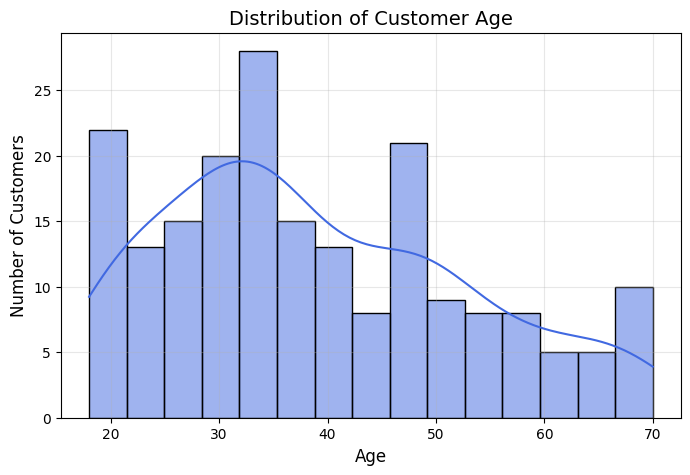

In [29]:
# Create a figure
plt.figure(figsize=(8,5))

# Plot histogram with KDE
sns.histplot(
    data=df,
    x="Age",
    bins=15,
    kde=True,
    color="royalblue"
)

# Add title and labels
plt.title("Distribution of Customer Age", fontsize=14)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

# Display grid
plt.grid(alpha=0.3)

# Save the figure
plt.savefig("../images/age_distribution.png", dpi=300, bbox_inches="tight")

# Show the plot
plt.show()

### Observation

- The majority of customers are between **25 and 40 years** of age.
- The highest concentration of customers is around **30–35 years**.
- The number of customers decreases gradually after the age of **50 years**.
- Very few customers are above **60 years**, indicating that the mall mainly attracts young and middle-aged adults.

## Step 3.7: Gender Distribution

Understanding the gender distribution helps identify the proportion of male and female customers. This information can support businesses in designing targeted marketing campaigns and evaluating whether the customer base is balanced.

In [30]:

df["Gender"].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

In [31]:
# Percentage distribution of gender
gender_percentage = (df["Gender"].value_counts(normalize=True) * 100).round(2)

gender_percentage

Gender
Female    56.0
Male      44.0
Name: proportion, dtype: float64

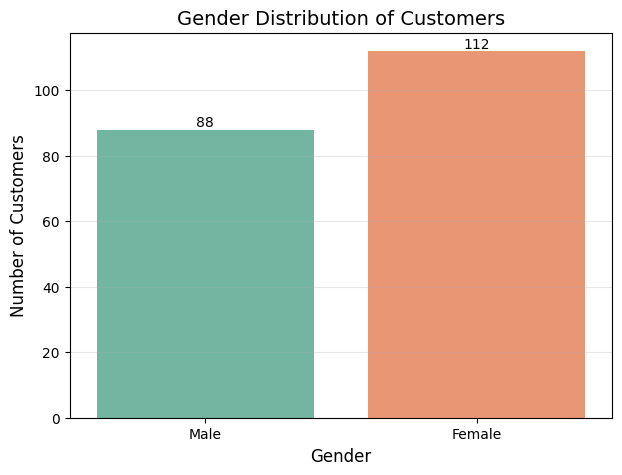

In [32]:
# Create figure
plt.figure(figsize=(7,5))

# Create count plot
ax = sns.countplot(
    data=df,
    x="Gender",
    hue="Gender",      # avoids future seaborn warnings
    palette="Set2",
    legend=False
)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container)

# Title and labels
plt.title("Gender Distribution of Customers", fontsize=14)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

# Grid
plt.grid(axis="y", alpha=0.3)

# Save image
plt.savefig("../images/gender_distribution.png", dpi=300, bbox_inches="tight")

# Display plot
plt.show()

### Observation

- The dataset contains both male and female customers.
- Female customers slightly outnumber male customers.
- The gender distribution is relatively balanced, making the dataset suitable for customer segmentation.
- Businesses can design marketing campaigns for both genders while considering the slightly larger female customer base.

## Step 3.8: Annual Income Distribution

Annual income is one of the most important features for customer segmentation. Analyzing its distribution helps understand the purchasing capacity of customers and identify low-, middle-, and high-income groups.

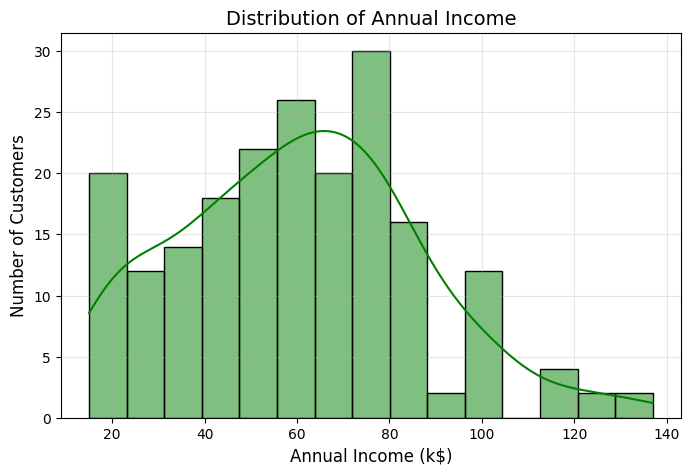

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Annual Income (k$)",
    bins=15,
    kde=True,
    color="green"
)


plt.title("Distribution of Annual Income", fontsize=14)
plt.xlabel("Annual Income (k$)", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)


plt.grid(alpha=0.3)


plt.savefig("../images/income_distribution.png",
            dpi=300,
            bbox_inches="tight")


plt.show()

### Observation

- Annual income ranges from **15k to 137k dollars**.
- Most customers fall within the **middle-income** range.
- Both low-income and high-income customers are present, indicating a diverse customer base.
- Income appears to be reasonably distributed, making it a useful feature for customer segmentation.

In [34]:
# Summary statistics for Annual Income
print("Minimum Income :", df["Annual Income (k$)"].min())
print("Maximum Income :", df["Annual Income (k$)"].max())
print("Average Income :", round(df["Annual Income (k$)"].mean(), 2))
print("Median Income  :", df["Annual Income (k$)"].median())

Minimum Income : 15
Maximum Income : 137
Average Income : 60.56
Median Income  : 61.5


## Step 3.9: Spending Score Distribution

The Spending Score is assigned by the mall based on customer purchasing behavior. Analyzing its distribution helps identify whether customers generally spend more or less and whether spending behavior varies across the customer base.

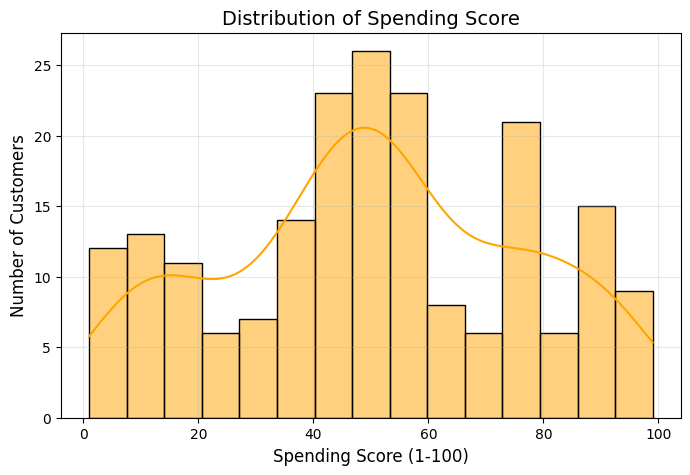

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Spending Score (1-100)",
    bins=15,
    kde=True,
    color="orange"
)
plt.title("Distribution of Spending Score", fontsize=14)
plt.xlabel("Spending Score (1-100)", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.grid(alpha=0.3)

plt.savefig(
    "../images/spending_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [36]:
# Summary statistics for Spending Score
print("Minimum Spending Score :", df["Spending Score (1-100)"].min())
print("Maximum Spending Score :", df["Spending Score (1-100)"].max())
print("Average Spending Score :", round(df["Spending Score (1-100)"].mean(), 2))
print("Median Spending Score  :", df["Spending Score (1-100)"].median())

Minimum Spending Score : 1
Maximum Spending Score : 99
Average Spending Score : 50.2
Median Spending Score  : 50.0


### Observation

- Spending scores range from **1 to 99**.
- The average spending score is approximately **50**, indicating a balanced mix of low and high spenders.
- The distribution shows that customers have diverse purchasing behaviors.
- Spending Score is expected to be one of the most influential features during customer segmentation.

## Step 3.10: Outlier Detection Using Boxplots

A boxplot is used to identify outliers in numerical features. Outliers are observations that lie far away from the majority of the data. Detecting outliers helps determine whether they should be retained or removed before applying machine learning algorithms.

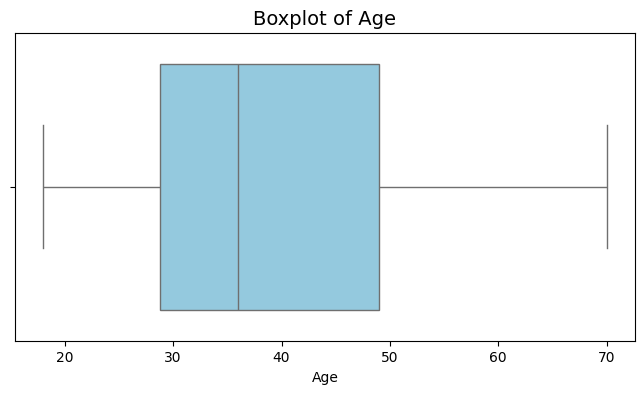

In [37]:
# Create figure
plt.figure(figsize=(8,4))

# Boxplot
sns.boxplot(
    x=df["Age"],
    color="skyblue"
)

# Title
plt.title("Boxplot of Age", fontsize=14)

# Save image
plt.savefig(
    "../images/age_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

# Show plot
plt.show()

### Observation

- The Age feature shows very few or no significant outliers.
- Most customers fall within a reasonable age range.
- The age distribution appears suitable for clustering without removing any observations.

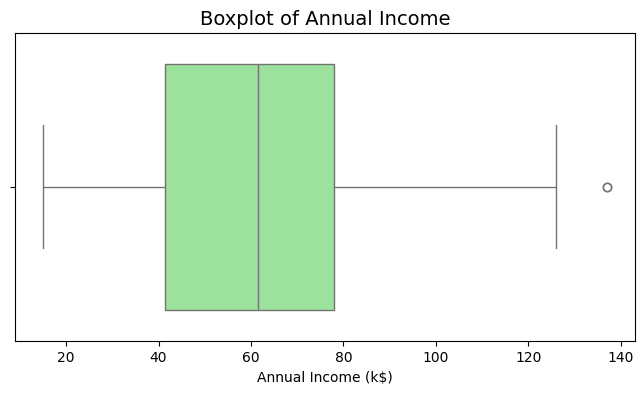

In [38]:
# Create figure
plt.figure(figsize=(8,4))

# Boxplot
sns.boxplot(
    x=df["Annual Income (k$)"],
    color="lightgreen"
)

# Title
plt.title("Boxplot of Annual Income", fontsize=14)

# Save image
plt.savefig(
    "../images/income_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

# Show plot
plt.show()

### Observation

- Annual Income does not contain extreme outliers.
- Income values are spread across different levels, representing a diverse customer base.
- The feature is appropriate for customer segmentation.

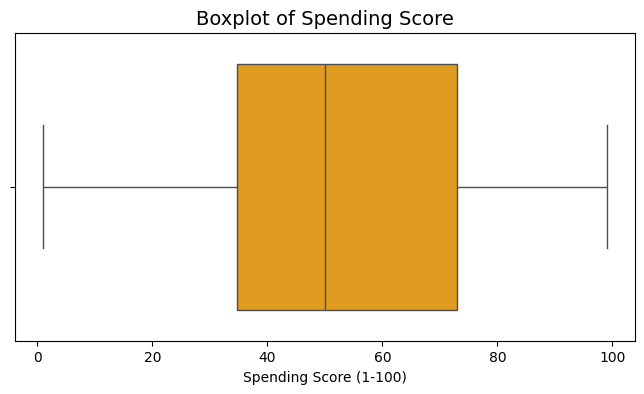

In [39]:
# Create figure
plt.figure(figsize=(8,4))

# Boxplot
sns.boxplot(
    x=df["Spending Score (1-100)"],
    color="orange"
)

# Title
plt.title("Boxplot of Spending Score", fontsize=14)

# Save image
plt.savefig(
    "../images/spending_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

# Show plot
plt.show()

### Observation

- Spending Score does not show any extreme outliers.
- Customers exhibit a wide range of spending behavior, which is useful for clustering.
- No outlier treatment is required for this feature.

## Step 3.11: Correlation Analysis

Correlation analysis helps measure the strength and direction of relationships between numerical variables. A correlation heatmap provides a visual representation of these relationships, making it easier to identify patterns before applying machine learning algorithms.

In [40]:
numeric_df = df.select_dtypes(include=["number"])

numeric_df.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,2,21,15,81
2,3,20,16,6
3,4,23,16,77
4,5,31,17,40


In [41]:

correlation_matrix = numeric_df.corr()

correlation_matrix

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,1.000000,-0.026763,0.977548,0.013835
Age,-0.026763,1.000000,-0.012398,-0.327227
Annual Income (k$),0.977548,-0.012398,1.000000,0.009903
Spending Score (1-100),0.013835,-0.327227,0.009903,1.000000


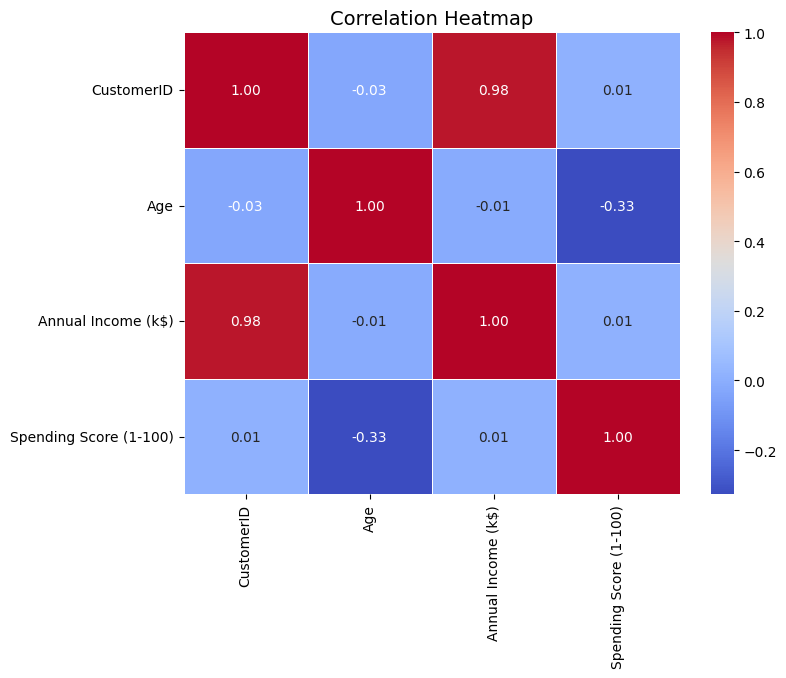

In [42]:

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap", fontsize=14)


plt.savefig(
    "../images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

### Observation

- CustomerID is an identifier and will not be used for clustering.
- Age has a weak negative correlation with Spending Score, indicating that spending tends to decrease slightly with age.
- Annual Income has little to no linear correlation with Spending Score.
- Since no strong correlations exist among the main customer features, clustering techniques such as K-Means can still identify meaningful groups based on the combination of multiple features.

## Step 3.12: Scatter Plot Analysis

A scatter plot helps visualize the relationship between Annual Income and Spending Score. Before applying K-Means clustering, this visualization allows us to identify whether natural customer groups exist in the dataset.

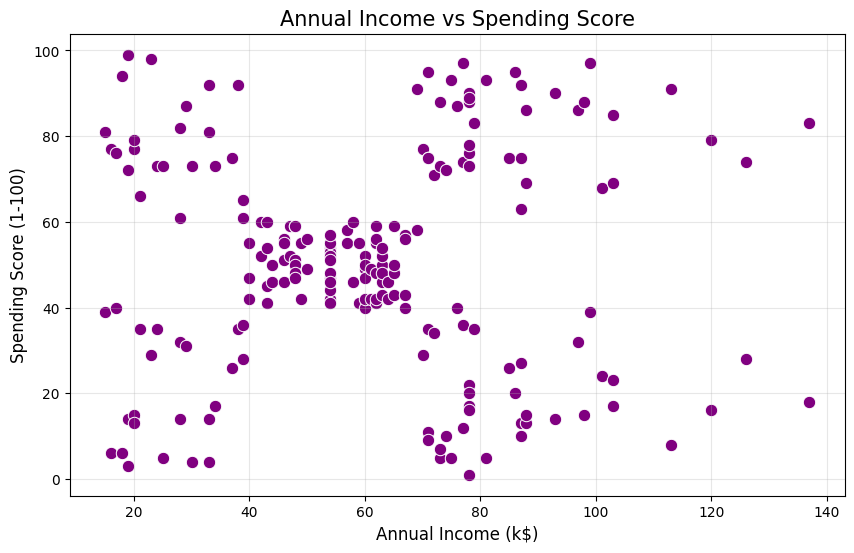

In [43]:

plt.figure(figsize=(10,6))


sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    s=80,
    color="purple"
)

plt.title("Annual Income vs Spending Score", fontsize=15)

plt.xlabel("Annual Income (k$)", fontsize=12)
plt.ylabel("Spending Score (1-100)", fontsize=12)

plt.grid(alpha=0.3)

plt.savefig(
    "../images/income_vs_spending.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- The scatter plot indicates that customers are not randomly distributed.
- Several natural groups can be visually identified based on Annual Income and Spending Score.
- Customers with similar income levels exhibit different spending behaviors.
- This visualization suggests that K-Means clustering is suitable for identifying meaningful customer segments.

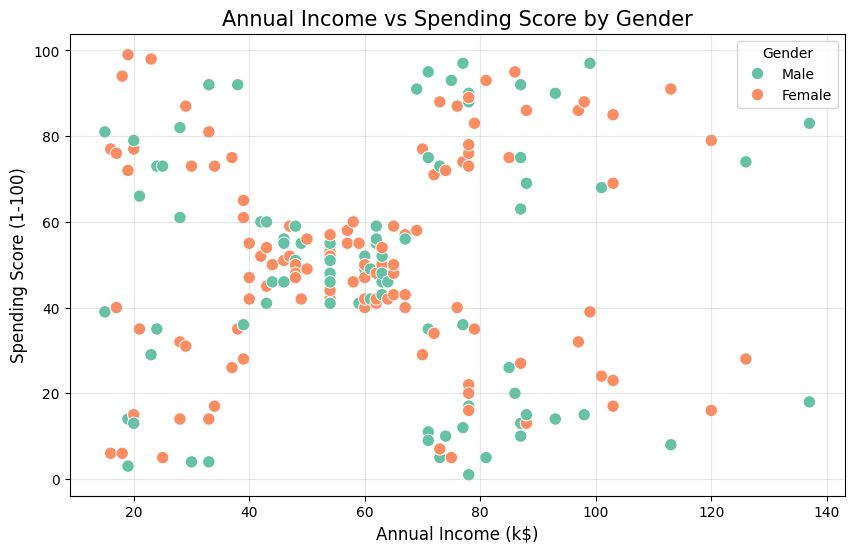

In [44]:

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Gender",
    palette="Set2",
    s=80
)

plt.title("Annual Income vs Spending Score by Gender", fontsize=15)
plt.xlabel("Annual Income (k$)", fontsize=12)
plt.ylabel("Spending Score (1-100)", fontsize=12)

plt.grid(alpha=0.3)

plt.savefig(
    "../images/income_vs_spending_gender.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Phase 4: Data Preprocessing

## Step 4.1: Feature Selection

Feature selection is the process of choosing the most relevant variables for machine learning. For customer segmentation, we select **Age**, **Annual Income**, and **Spending Score** because they describe customer characteristics and purchasing behavior. The **CustomerID** column is excluded since it is only an identifier, and **Gender** is not included in this clustering model.

In [45]:

X = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]

X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [46]:
# Check dimensions of the feature matrix
print("Shape of X:", X.shape)

Shape of X: (200, 3)


In [47]:
# Check missing values
X.isnull().sum()

Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

### Observation

- Three numerical features were selected for clustering: **Age**, **Annual Income**, and **Spending Score**.
- CustomerID was excluded because it is only a unique identifier.
- Gender was not included in this clustering model.
- The selected features contain no missing values and are ready for preprocessing.

## Step 4.2: Feature Scaling

Feature scaling is an important preprocessing step for distance-based machine learning algorithms such as K-Means Clustering. Since the selected features have different ranges, StandardScaler is used to standardize the data so that each feature has a mean of approximately 0 and a standard deviation of 1.

In [48]:
from sklearn.preprocessing import StandardScaler

In [49]:

scaler = StandardScaler()

In [50]:
X_scaled = scaler.fit_transform(X)

In [51]:
X_scaled[:5]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

In [52]:
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled_df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


In [53]:

X_scaled_df.mean()

Age                      -1.021405e-16
Annual Income (k$)       -2.131628e-16
Spending Score (1-100)   -1.465494e-16
dtype: float64

In [54]:

X_scaled_df.std()

Age                       1.002509
Annual Income (k$)        1.002509
Spending Score (1-100)    1.002509
dtype: float64

### Observation

- The selected features were standardized using **StandardScaler**.
- Feature scaling ensures that all variables contribute equally during distance calculations.
- After scaling, the features have a mean close to **0** and a standard deviation close to **1**.
- The scaled dataset is now ready for K-Means clustering.

# Phase 5: K-Means Clustering

## Step 5.1: Finding the Optimal Number of Clusters (Elbow Method)

The Elbow Method is used to determine the optimal number of clusters for K-Means clustering. It computes the Within-Cluster Sum of Squares (WCSS) for different values of K and identifies the point where adding more clusters provides diminishing improvements.

In [56]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init="k-means++",
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

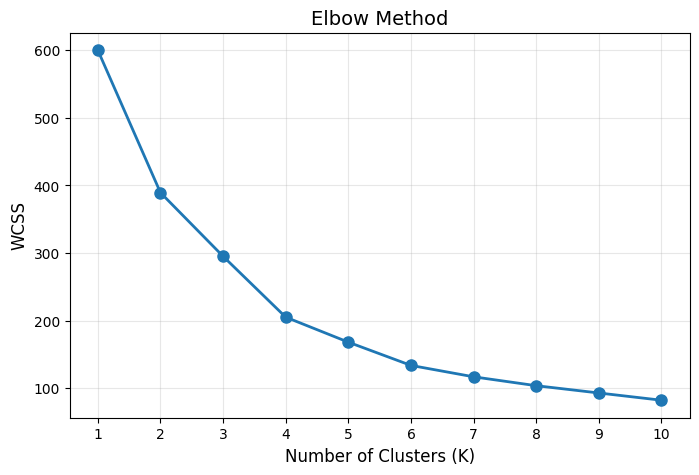

In [57]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o",
    linewidth=2,
    markersize=8
)

plt.title("Elbow Method", fontsize=14)
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("WCSS", fontsize=12)

plt.xticks(range(1,11))
plt.grid(alpha=0.3)

plt.savefig(
    "../images/elbow_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- The Elbow Method shows a sharp decrease in WCSS as the number of clusters increases.
- After a certain point, the reduction in WCSS becomes gradual.
- The "elbow" of the curve indicates the optimal number of clusters.
- Based on the graph, **K = 5** is selected as the optimal number of clusters for customer segmentation.

## Step 5.2: Training the K-Means Model

After determining the optimal number of clusters, the K-Means algorithm is trained using K = 5. The algorithm assigns each customer to the nearest cluster based on the selected features.

In [60]:
kmeans = KMeans(
    n_clusters=5,
    init="k-means++",
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [61]:
df["Cluster"] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


### Observation

- The K-Means model successfully assigned each customer to one of the five clusters.
- A new column named **Cluster** was added to the dataset.
- Each customer now belongs to a specific customer segment.

## Step 5.3: Cluster Distribution

The distribution of customers across clusters helps evaluate how balanced the segmentation is.

In [62]:
df["Cluster"].value_counts().sort_index()

Cluster
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64

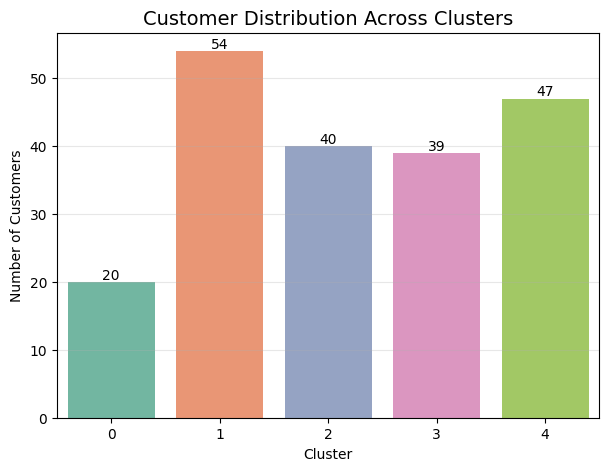

In [63]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="Cluster",
    hue="Cluster",
    palette="Set2",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Distribution Across Clusters", fontsize=14)
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.grid(axis="y", alpha=0.3)

plt.savefig(
    "../images/cluster_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Customers are divided into five distinct clusters.
- Each cluster represents a unique customer segment.
- The distribution indicates that the K-Means algorithm successfully partitioned the dataset.

## Step 5.4: Visualizing Customer Segments

The clustered customers are visualized using a scatter plot based on **Annual Income** and **Spending Score**. Each color represents a different customer segment, while the black 'X' markers indicate the cluster centroids learned by the K-Means algorithm.

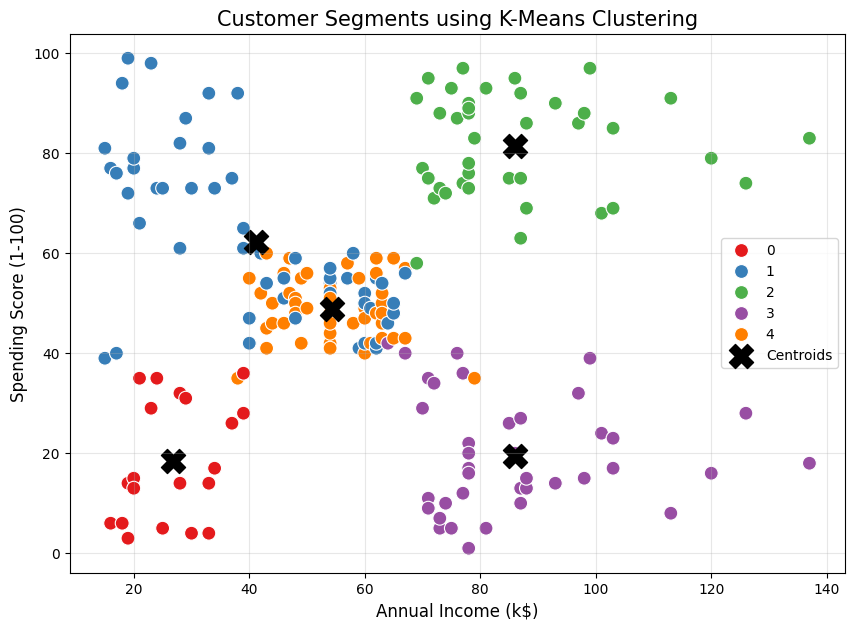

In [64]:
# Create figure
plt.figure(figsize=(10, 7))

# Scatter plot of clusters
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set1",
    s=100
)

# Plot cluster centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centroids[:, 1],
    centroids[:, 2],
    s=300,
    c="black",
    marker="X",
    label="Centroids"
)

# Title and labels
plt.title("Customer Segments using K-Means Clustering", fontsize=15)
plt.xlabel("Annual Income (k$)", fontsize=12)
plt.ylabel("Spending Score (1-100)", fontsize=12)

plt.legend()

plt.grid(alpha=0.3)

plt.savefig(
    "../images/customer_segments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- The K-Means algorithm successfully identified **five distinct customer segments**.
- Customers within the same cluster exhibit similar purchasing behavior.
- The black 'X' markers represent the cluster centroids.
- The segmentation provides valuable insights for designing targeted marketing strategies.

## Step 5.5: Cluster Summary

To better understand each customer segment, the average values of Age, Annual Income, and Spending Score are calculated for every cluster.

In [65]:
cluster_summary = df.groupby("Cluster")[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]].mean().round(2)

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.25,26.75,18.35
1,25.19,41.09,62.24
2,32.88,86.10,81.53
3,39.87,86.10,19.36
4,55.64,54.38,48.85


In [66]:
cluster_summary.style.background_gradient(cmap="YlGnBu")

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.250000,26.750000,18.350000
1,25.190000,41.090000,62.240000
2,32.880000,86.100000,81.530000
3,39.870000,86.100000,19.360000
4,55.640000,54.380000,48.850000


### Observation

- Each cluster has unique characteristics based on age, annual income, and spending score.
- These average values help interpret customer behavior and assign meaningful business labels to each segment.

In [67]:
cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.25,26.75,18.35
1,25.19,41.09,62.24
2,32.88,86.10,81.53
3,39.87,86.10,19.36
4,55.64,54.38,48.85


In [68]:
cluster_names = {
    0: "VIP Customers",
    1: "High Income, Low Spending",
    2: "Budget Customers",
    3: "Regular Customers",
    4: "Young High Spenders"
}

df["Customer Segment"] = df["Cluster"].map(cluster_names)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Customer Segment
0,1,Male,19,15,39,1,"High Income, Low Spending"
1,2,Male,21,15,81,1,"High Income, Low Spending"
2,3,Female,20,16,6,0,VIP Customers
3,4,Female,23,16,77,1,"High Income, Low Spending"
4,5,Female,31,17,40,1,"High Income, Low Spending"


## Step 5.7: Customer Segment Distribution

The following table shows the number of customers in each business segment after assigning descriptive labels.

In [69]:
segment_distribution = df["Customer Segment"].value_counts()

segment_distribution

Customer Segment
High Income, Low Spending    54
Young High Spenders          47
Budget Customers             40
Regular Customers            39
VIP Customers                20
Name: count, dtype: int64

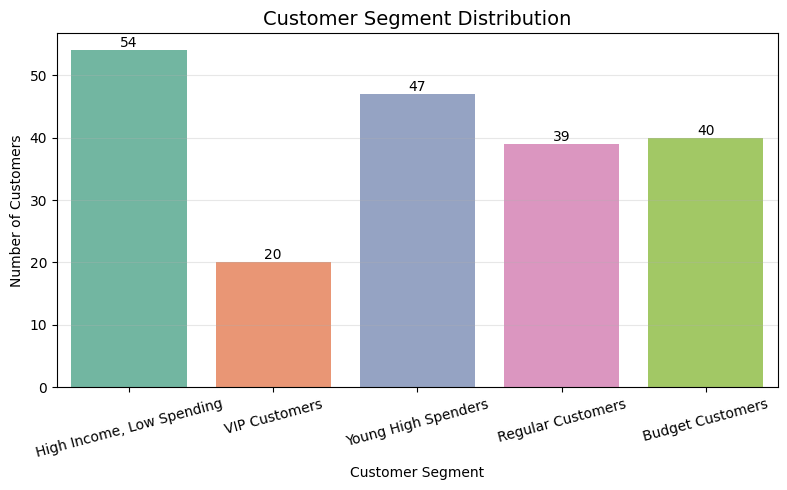

In [70]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Customer Segment",
    hue="Customer Segment",
    palette="Set2",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Segment Distribution", fontsize=14)
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../images/customer_segment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- The customer base has been successfully divided into meaningful business segments.
- Each segment represents customers with similar purchasing behavior.
- These segments can support personalized marketing campaigns, loyalty programs, and strategic business decisions.

# Phase 6: Exporting the Final Dataset

## Step 6.1: Export Clustered Dataset

The final dataset, including the assigned customer segments, is exported as a CSV file. This file can be used for reporting, dashboard creation, or further business analysis.

In [71]:
# Export final dataset
df.to_csv("../reports/customer_segments.csv", index=False)

print("Dataset exported successfully!")

Dataset exported successfully!


In [72]:
# Save cluster summary
cluster_summary.to_csv("../reports/cluster_summary.csv")

print("Cluster summary exported successfully!")

Cluster summary exported successfully!
